In [370]:
import requests
import json
from pydantic import BaseModel
from typing import List, Tuple
from fake_useragent import UserAgent
import time
import matplotlib.pyplot as plt

from bet.config import settings

In [266]:
class Team(BaseModel):
    name: str

class Comment(BaseModel):
    text: str
    type: str
    periodName: str = None
    time: int
    isHome: bool = None
    
class Partida(BaseModel):
    id: int
    homeTeam: Team
    awayTeam: Team
    comments: List[Comment] = None 
    
    

In [313]:
def get_partidas_por_data(data: str) -> List[Partida]:
    """
    Busca todas as partidas de um determinado dia com time da casa, de fora e o id.
    A data tem que ta no formato YYYY-MM-DD
    """
    ua = UserAgent()
    headers = {
        'User-Agent': ua.random
    }
    url = f"https://www.sofascore.com/api/v1/sport/football/scheduled-events/{data}"
    partidas = requests.get(url=url, headers=headers).json()['events']
    return [Partida(**p) for p in partidas]

def get_partida_comments_by_id(partida: Partida) -> Partida:
    ua = UserAgent()
    headers = {
        'User-Agent': ua.random
    }
    urls = {
        'pt': f"https://www.sofascore.com/api/v1/event/{partida.id}/comments/pt",
        'en': f"https://www.sofascore.com/api/v1/event/{partida.id}/comments/en",
    }
    response = requests.get(url=urls['pt'], headers=headers, timeout=10)
    if "comments" not in response.json().keys():
        response = requests.get(url=urls['en'], headers=headers)
        if "comments" not in response.json().keys():
            return None
   
    comments = response.json()['comments']
    comments_list = [Comment(**comment) for comment in comments]
    partida.comments = comments_list

    return partida

def get_all_partidas_comments(partidas: List[Partida]) -> List[Partida]:
    partidas_com_comments = []
    for partida in partidas:
        partida_com_comment = get_partida_comments_by_id(partida)
        if partida_com_comment:
            partidas_com_comments.append(partida_com_comment)
    return partidas_com_comments

def get_partidas_com_gol_so_2nd(partidas: List[Partida]) -> List[Partida]:
    partidas_com_gol_so_2nd = []
    for partida in partidas:
        comment_1nd = [
            comment 
            for comment in partida.comments 
            if comment.periodName == '1ST' 
            and (comment.type == 'scoreChange' or comment.type == 'penaltyScored')
        ]
        comment_2nd = [
            comment 
            for comment in partida.comments 
            if comment.periodName == '2ND' 
            and (comment.type == 'scoreChange' or comment.type == 'penaltyScored')
        ]
        if comment_1nd == [] and comment_2nd != []:
            partida.comments = comment_2nd
            partidas_com_gol_so_2nd.append(partida)
    return partidas_com_gol_so_2nd

def get_partidas_gols_mais10min(partidas: List[Partida]):
    contador = 0
    for partida in partidas_com_gols_2nd:
        comment_size = len(partida.comments)
        if comment_size == 1:
            contador += 1
        else:
            time_primero_gol = partida.comments[-1].time
            time_segundo_gol = partida.comments[-2].time
            if time_segundo_gol - time_primero_gol >= 10:
                contador += 1
    return len(partidas), contador
    
def calcular_rentabilidade(dado_rentabilidade: Tuple, pct_ganho: int):
    return (dado_rentabilidade[1] * pct_ganho) - ((dado_rentabilidade[0]- dado_rentabilidade[1]) * 100)

In [344]:
datas = [
    '2024-09-15',
    '2024-09-16',
    '2024-09-17',
    '2024-09-18',
    '2024-09-19',
    '2024-09-20',
    '2024-09-21',
    '2024-09-22',
    '2024-09-23',
    '2024-09-24',
    '2024-09-25',
    '2024-09-26',
    '2024-09-27',
    '2024-09-28',
    '2024-09-29',
    '2024-09-30',
    '2024-10-01',
    '2024-10-02',
    '2024-10-03',
    '2024-10-04',
    '2024-10-05',
    '2024-10-06',
    '2024-10-07',
    '2024-10-08',
    '2024-10-09',
    '2024-10-10',
    '2024-10-11',
    '2024-10-12',
    '2024-10-13',
    '2024-10-14'
]

In [335]:
#dados_para_testar_rendabilidade = []
for data in datas:
    print(f"Processando {data}")
    partidas = get_partidas_por_data(data)
    partidas_com_comments = get_all_partidas_comments(partidas)
    partidas_com_gols_2nd = get_partidas_com_gol_so_2nd(partidas_com_comments)
    dado_rentabilidade = get_partidas_gols_mais10min(partidas_com_gols_2nd)
    dados_para_testar_rendabilidade.append(dado_rentabilidade)
    

Processando 2024-09-15


KeyboardInterrupt: 

In [337]:
dados_para_testar_rendabilidade

[(51, 37),
 (27, 21),
 (19, 17),
 (27, 20),
 (22, 16),
 (24, 19),
 (55, 43),
 (55, 44),
 (25, 19),
 (15, 12),
 (17, 13),
 (17, 13),
 (30, 21),
 (70, 57),
 (72, 63),
 (39, 36),
 (19, 18),
 (19, 15),
 (19, 14),
 (39, 35),
 (73, 61),
 (72, 58),
 (29, 23),
 (7, 6),
 (6, 5),
 (8, 7),
 (15, 14),
 (28, 22),
 (28, 23),
 (23, 20)]

In [277]:
totais = [total_acerto[0] for total_acerto in dados_para_testar_rendabilidade]
acertos = [total_acerto[1] for total_acerto in dados_para_testar_rendabilidade]   

In [278]:
total = sum(totais)
total

385

In [279]:
acerto = sum(acertos)
acerto

321

In [372]:
cont = 0
for v in dados_para_testar_rendabilidade[16:]:
    result = calcular_rentabilidade(v, 25)
    cont += result
cont

1625

In [ ]:
dados_backtest_gol_2nd_

In [326]:
len(partidas)

185

In [331]:
partidas_analisadas = []
for data in datas:
    print(f"Processando {data}")
    partidas = get_partidas_por_data(data)
    partidas_analisadas.append(partidas)

Processando 2024-09-29
Processando 2024-09-30
Processando 2024-10-01
Processando 2024-10-02
Processando 2024-10-03
Processando 2024-10-04
Processando 2024-10-05
Processando 2024-10-06
Processando 2024-10-07
Processando 2024-10-08
Processando 2024-10-09
Processando 2024-10-10
Processando 2024-10-11
Processando 2024-10-12
Processando 2024-10-13
Processando 2024-10-14


In [332]:
total_partidas_analisadas = sum([len(partidas) for partidas in partidas_analisadas])

In [333]:
total_partidas_analisadas

5508

In [339]:
len(datas)

30

In [352]:
dados_analizados_metodo_10min = []
for i in range(len(datas)):
    dados_por_dia = {}
    dados_por_dia['data'] = datas[i]
    dados_por_dia['partida_gol_2nd'] = dados_para_testar_rendabilidade[i][0]
    dados_por_dia['partida_gol_apos_10m'] = dados_para_testar_rendabilidade[i][1]
    dados_por_dia['lep_dia'] = calcular_rentabilidade(dados_para_testar_rendabilidade[i], 25)
    dados_analizados_metodo_10min.append(dados_por_dia)
    

In [363]:
with open(f"{settings.data_dir}/back_test/dados_analizados_metodo_10min.json", "w", encoding="utf-8") as f:
    json.dump(dados_analizados_metodo_10min, f)

In [368]:
#dados_analizados_metodo_10min

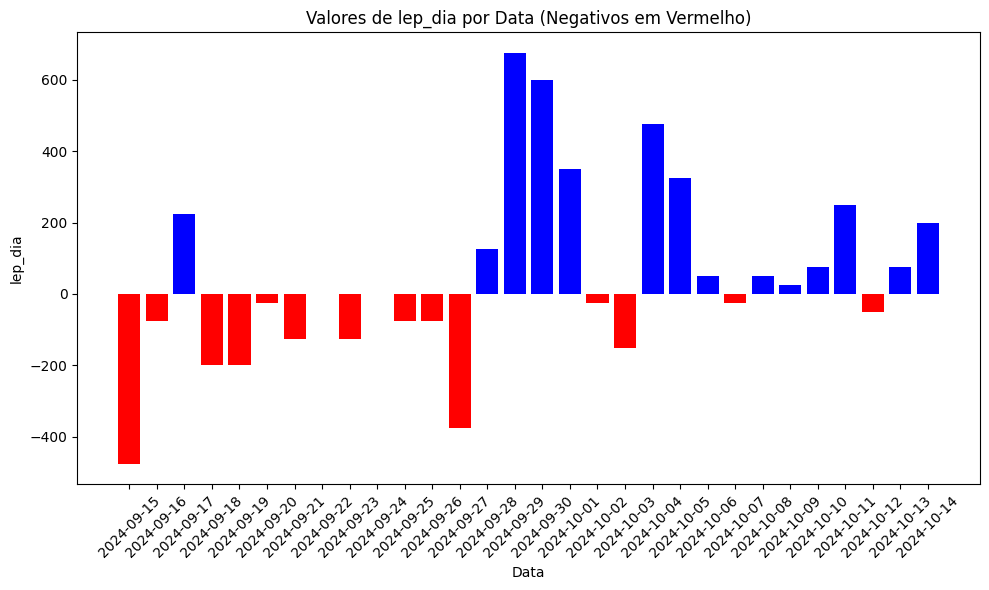

In [371]:
# Extraindo as datas e os valores de lep_dia
datas = [item['data'] for item in dados_analizados_metodo_10min]
lep_dia = [item['lep_dia'] for item in dados_analizados_metodo_10min]

# Definindo as cores (vermelho para negativos e azul para positivos)
cores = ['red' if valor < 0 else 'blue' for valor in lep_dia]

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(datas, lep_dia, color=cores)

# Adicionando rótulos e título
plt.xlabel('Data')
plt.ylabel('lep_dia')
plt.title('Valores de lep_dia por Data (Negativos em Vermelho)')

# Exibindo o gráfico
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [349]:
for i in range(len(datas)):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
